In [3]:
from myutils import *
from src import *

In [7]:
file_tree = [
    # r'C:\Users\Administrator\Desktop\data\10.22\spade_*.npz', 
    # r'C:\Users\Administrator\Desktop\data\10.21.a\spade_*.npz',
    # r'C:\Users\Administrator\Desktop\data\10.21.b\spade_*.npz', 
    # r'C:\Users\Administrator\Desktop\data\10.19\spade_*.npz',
    # r'C:\Users\Administrator\Desktop\data\10.28.a\spade_*.npz',
    # r'C:\Users\Administrator\Desktop\data\10.28.b\spade_*.npz'
    
    # '/Volumes/nvmeOFwiz/raw/estimates/10.19/spade*',
    # '/Volumes/nvmeOFwiz/raw/estimates/10.21.a/spade*',
    # '/Volumes/nvmeOFwiz/raw/estimates/10.21.b/spade*',
    # '/Volumes/nvmeOFwiz/raw/estimates/10.22/spade*',

    # r'C:\Users\Administrator\Desktop\11.2\estimates\di*',
    # r'C:\Users\Administrator\Desktop\11.2\estimates\3sigma\di*'

    r'F:\__estimates__\20241104\spade*',
]

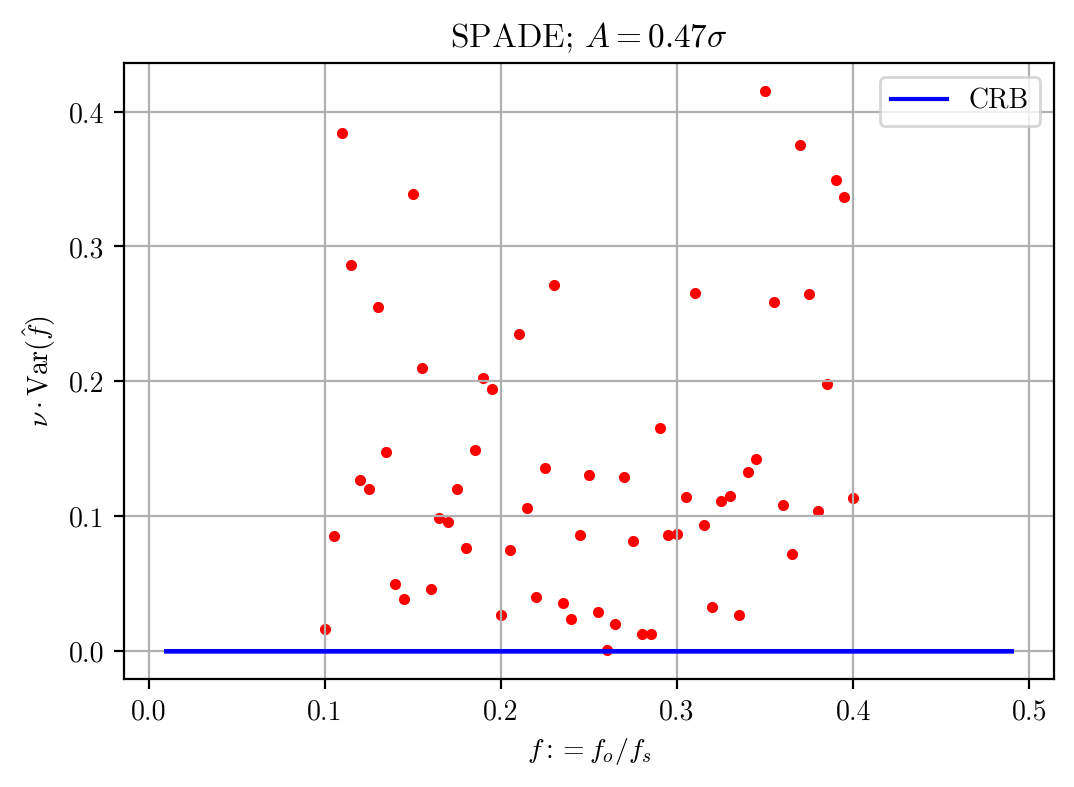

In [8]:
x_axis = np.linspace(0, 0.5, 1000)[20: -20]
A = 5 * DMD.PIXEL_SIZE / 2

plot(x_axis, FIM_CRB().crb_list(A, x_axis), 'b', label='CRB')
plot(x_axis, 0.7 * FIM_CRB().crb_list(A, x_axis), 'b')
plot(x_axis, 1.3 * FIM_CRB().crb_list(A, x_axis), 'b')

for file in file_tree:
    for f in glob(file):
        c = LoadEstimates(f) 
        scatter(c.metadata.ground_truth, c.frequency_estmates.var(ddof=1) * c.photons.mean(), marker='.', c='r')


plt.xlabel(r'$f := f_o / f_s$')
plt.ylabel(r'$\nu\cdot{\rm Var}(\hat f)$')
plt.title(rf'SPADE; $A = {np.round(5 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')
plt.show()

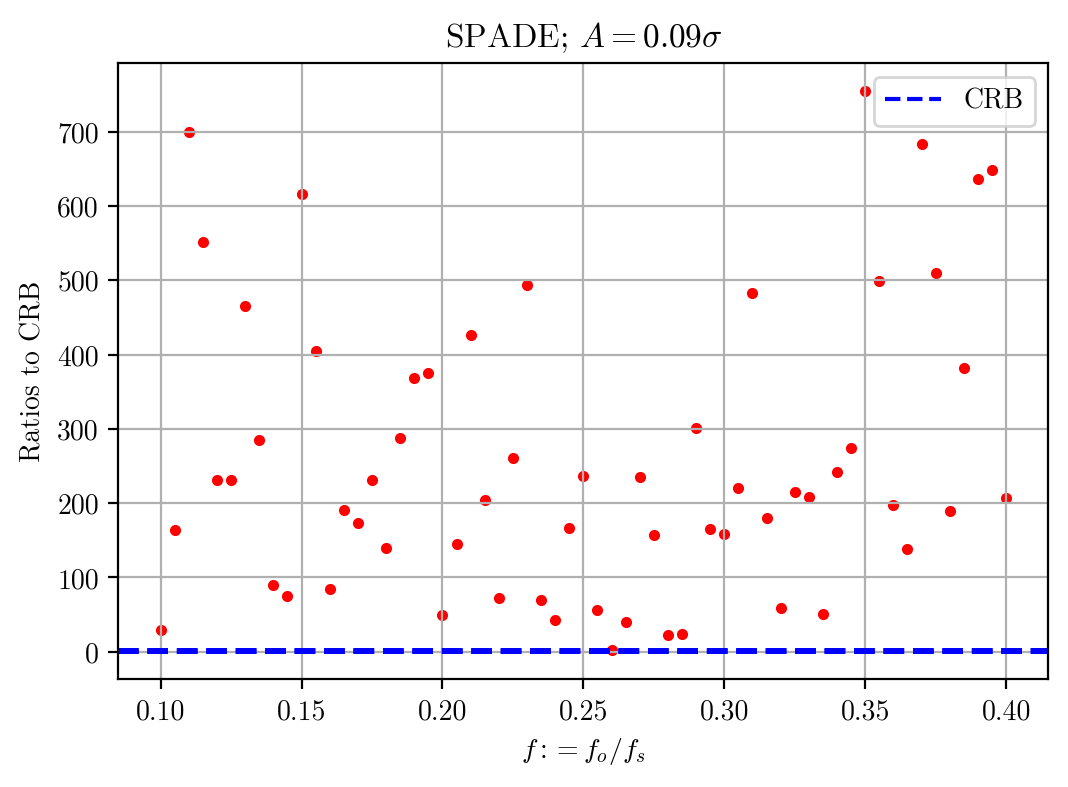

In [10]:
for file in file_tree:
    for f in glob(file):
        c = LoadEstimates(f)
        x = c.metadata.ground_truth
        y = c.frequency_estmates.var(ddof=1) * c.photons.mean() / FIM_CRB().crb(c.metadata.amplitude, x)
        scatter(x, y, marker='.', c='r')


axline(0.7, c='b', w=2)
axline(1, c='b', w=2)
axline(1.3, c='b', w=2)

plot([], [], 'b--', label='CRB')

plt.xlabel(r'$f := f_o / f_s$')
plt.ylabel(r'Ratios to CRB')
plt.title(rf'SPADE; $A = {np.round(1 * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')
plt.show()